# Ускорение инференса UNet – первые эксперименты

**Цель:**  
- Создать бейзлайн FP16 на реальном датасете (PASCAL VOC)  
- Измерить латентность для разных batch size  
- Профилировать модель  
- Применить `torch.compile` и сравнить ускорение  
- Оценить влияние на качество (IoU)

### 1. Импорты и настройка

In [1]:
!pip install segmentation-models-pytorch torch torchvision matplotlib seaborn pandas tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 KB 1.9 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
from tqdm import tqdm
from torch.profiler import profile, record_function, ProfilerActivity

import segmentation_models_pytorch as smp

import utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Загрузка модели UNet

In [3]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=21          # 20 классов + фон в VOC
).to(device)
model.eval()
print("Model loaded.")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded.


### 3. Подготовка датасета (PASCAL VOC 2012)

Загружаем валидационную часть для оценки качества и небольшой поднабор для бенчмаркинга.

In [4]:
data_root = "./data/VOC2012"

# загрузка из утилс
train_loader, val_loader, test_loader = utils.load_voc_datasets(
    root=data_root,
    batch_size=1,           #только доя оценки iou используем batch_size=1
    num_workers=2,
    download=True           # загрузит, если нет локально
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

100%|██████████████████████████████████████████████████████████████████████████████| 2.00G/2.00G [25:39<00:00, 1.30MB/s]


Train batches: 1464
Val batches:   1449


### 4. Функции для бенчмаркинга

In [5]:
# проверка
x = torch.randn(1, 3, 224, 224).to(device)
lat = utils.measure_latency(model, x, num_runs=50, warmup=10)
print(f"Latency for batch 1: {lat:.2f} ms")

Latency for batch 1: 6.91 ms


### 5. Бенчмарк FP16 baseline (разные batch size)

In [14]:
batch_sizes = [1, 2, 4, 8, 16, 32]
latencies_fp16 = []

for bs in batch_sizes:
    x = torch.randn(bs, 3, 224, 224).to(device)
    lat = utils.measure_latency(model, x)
    latencies_fp16.append(lat)
    print(f"Batch size {bs:2d} -> {lat:.2f} ms")

df_fp16 = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_fp16})
df_fp16.to_csv("baseline_fp16.csv", index=False)
print("\nBaseline FP16 results saved.")

Batch size  1 -> 8.10 ms
Batch size  2 -> 8.53 ms
Batch size  4 -> 10.37 ms
Batch size  8 -> 17.36 ms
Batch size 16 -> 31.94 ms
Batch size 32 -> 61.61 ms

Baseline FP16 results saved.


### 6. Профилирование (top-10 операций по времени)

In [8]:
with profile(
    activities=[ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
) as prof:
    with record_function("model_inference"):
        for _ in range(10):
            _ = model(torch.randn(1, 3, 224, 224).to(device))
            torch.cuda.synchronize()

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

[W401 15:55:06.947901501 collection.cpp:1004] Warning: Failed to recover relationship between all profiler and kineto events: 3000 vs. 0  reassociated. (function reassociate)


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
void cudnn::engines_precompiled::nchwToNhwcKernel<fl...         0.00%       0.000us         0.00%       0.000us       0.000us     140.129ms        45.07%     140.129ms     175.162us           0 b           0 b           800  
sm86_xmma_fprop_implicit_gemm_indexed_tf32f32_tf32f3...         0.00%       0.000us         0.0

### 7. Применяем torch.compile

In [9]:
compiled_model = torch.compile(model, mode="reduce-overhead")
compiled_model.eval()

for _ in range(5):
    _ = compiled_model(torch.randn(1, 3, 224, 224).to(device))
torch.cuda.synchronize()

latencies_compile = []
for bs in batch_sizes:
    x = torch.randn(bs, 3, 224, 224).to(device)
    lat = utils.measure_latency(compiled_model, x)
    latencies_compile.append(lat)
    print(f"Compiled batch size {bs:2d} -> {lat:.2f} ms")

df_compile = pd.DataFrame({"batch_size": batch_sizes, "latency_ms": latencies_compile})
df_compile.to_csv("compiled.csv", index=False)

W0401 15:55:22.121000 733407 torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode
/home/r-lomovsky/blur_detection/demo/healthcheck_env/lib/python3.10/site-packages/torch/_inductor/cudagraph_trees.py:2442: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(


Compiled batch size  1 -> 7.43 ms


/home/r-lomovsky/blur_detection/demo/healthcheck_env/lib/python3.10/site-packages/torch/_inductor/cudagraph_trees.py:2442: UserWarning: Unable to hit fast path of CUDAGraphs because of pending, uninvoked backwards. Consider running with torch.no_grad() or using torch.compiler.cudagraph_mark_step_begin() before each model invocation
  warnings.warn(


Compiled batch size  2 -> 6.94 ms
Compiled batch size  4 -> 9.24 ms
Compiled batch size  8 -> 16.39 ms
Compiled batch size 16 -> 28.58 ms
Compiled batch size 32 -> 54.00 ms


### 8. Визуализация ускорения

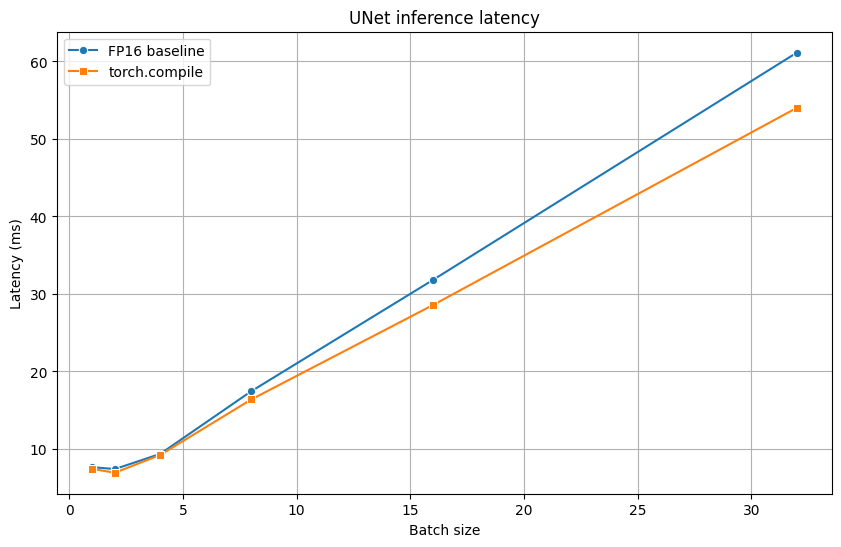

Speedup (FP16 / compiled):
  Batch  1: 1.03x
  Batch  2: 1.07x
  Batch  4: 1.01x
  Batch  8: 1.06x
  Batch 16: 1.11x
  Batch 32: 1.13x


In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=batch_sizes, y=latencies_fp16, marker='o', label='FP16 baseline')
sns.lineplot(x=batch_sizes, y=latencies_compile, marker='s', label='torch.compile')
plt.xlabel("Batch size")
plt.ylabel("Latency (ms)")
plt.title("UNet inference latency")
plt.grid(True)
plt.legend()
plt.savefig("latency_comparison.png", dpi=150)
plt.show()

# Ускорение
speedup = [fp16 / comp for fp16, comp in zip(latencies_fp16, latencies_compile)]
print("Speedup (FP16 / compiled):")
for bs, sp in zip(batch_sizes, speedup):
    print(f"  Batch {bs:2d}: {sp:.2f}x")

### 9. Оценка качества (IoU) на валидационном наборе

Сравниваем IoU для исходной и скомпилированной модели – они должны быть одинаковы.

In [11]:
def evaluate_iou(model, dataloader, device):
    """Вычисляет средний IoU по датасету."""
    model.eval()
    iou_list = []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating IoU"):
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            # Предполагаем, что модель возвращает логиты, применяем softmax
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            # Вычисляем IoU для каждого батча (batch_size=1)
            iou = utils.compute_iou(preds, masks, num_classes=21)
            iou_list.append(iou)
    return np.mean(iou_list)

print("Evaluating FP16 baseline IoU...")
iou_fp16 = evaluate_iou(model, val_loader, device)

print("Evaluating torch.compile IoU...")
iou_compile = evaluate_iou(compiled_model, val_loader, device)

print(f"\nMean IoU (FP16 baseline): {iou_fp16:.4f}")
print(f"Mean IoU (torch.compile):  {iou_compile:.4f}")

Evaluating FP16 baseline IoU...


Evaluating IoU: 100%|███████████████████████████████████████████████████████████████| 1449/1449 [00:28<00:00, 50.29it/s]


Evaluating torch.compile IoU...


Evaluating IoU: 100%|███████████████████████████████████████████████████████████████| 1449/1449 [00:34<00:00, 42.26it/s]


Mean IoU (FP16 baseline): 0.0011
Mean IoU (torch.compile):  0.0011


### 10. Сохранение результатов и выводы

In [13]:
summary = pd.DataFrame({
    "Method": ["FP16 baseline", "torch.compile"],
    "Mean IoU": [iou_fp16, iou_compile],
    "Latency (batch=1, ms)": [latencies_fp16[0], latencies_compile[0]]
})
summary.to_csv("summary.csv", index=False)
print("Summary saved.")

Summary saved.
